In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings

In [2]:
# 标准版存档V0：
LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


## fa:

In [3]:
df_zsc=pd.read_csv("../data_processed\listings-paris_london-2306_2406.csv")
print(len(df_zsc))

C:\Users\yeliu\AppData\Local\Temp\ipykernel_35616\835472841.py:1: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_zsc=pd.read_csv("../data_processed\listings-paris_london-2306_2406.csv")


187851


[INFO] all output saved to '..\output_fa_all'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 187851 rows; df_items:47897 rows!



d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[INFO] kmo_model score (> 0.7) :0.8753926287668162

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


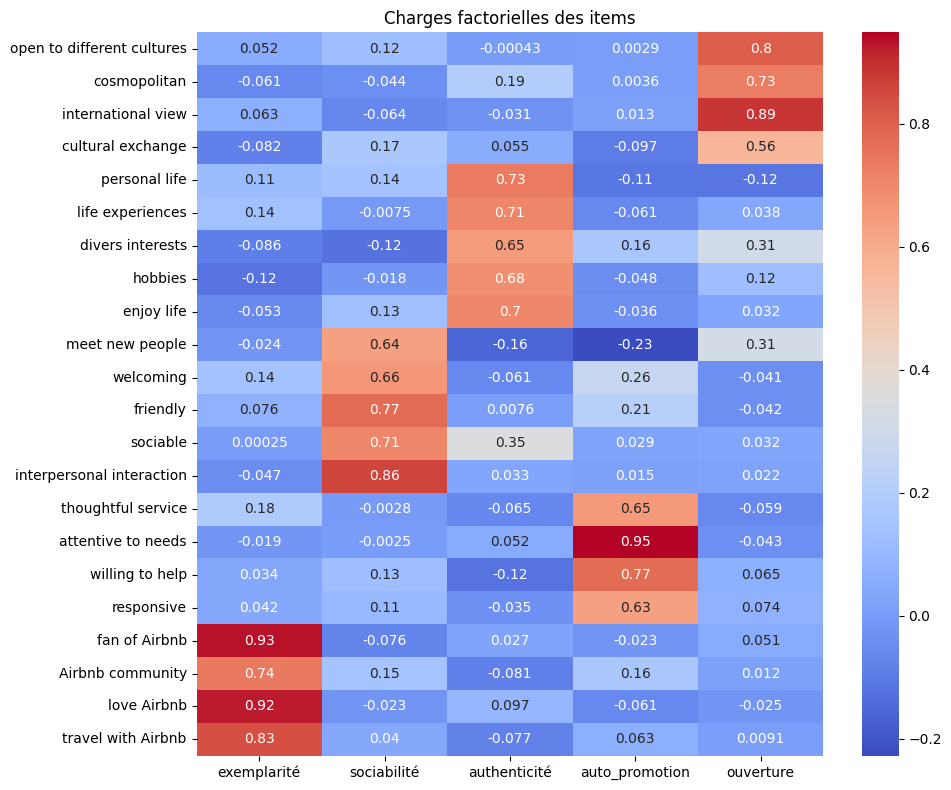

✅ [SAVE] heatmap of items saved to ..\output_fa_all\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6235967652727176
[INFO] mean UNIQ : 0.3764032347272824

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(47897, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,-0.063905,0.706891
authenticité,-0.138188,0.570419
sociabilité,0.494276,0.452539
auto_promotion,0.991483,-0.057213
exemplarité,0.510797,0.001664


✅[SAVE] scores df saved to ..\output_fa_all\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


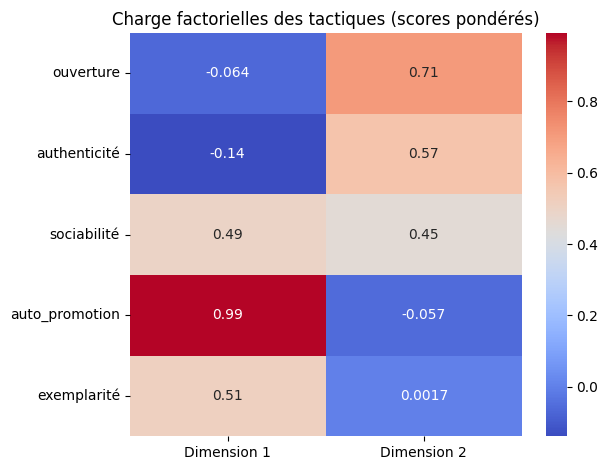

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,Airbnb community,love Airbnb,travel with Airbnb,is_paris,in_2024,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,157714,https://www.airbnb.com/rooms/157714,20230608145305,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377,...,0.875308,0.044266,0.261850,0,0,0.163545,-0.676712,0.986720,1.352565,0.196903
1,13913,https://www.airbnb.com/rooms/13913,20230608145305,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,0.001167,0.002715,0.000665,0,0,0.972676,0.380712,-1.326076,-0.971294,-0.740246
2,15400,https://www.airbnb.com/rooms/15400,20230608145305,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,0.826011,0.653901,0.381752,0,0,1.044898,1.190367,-0.679518,-0.597984,1.322457
3,306333,https://www.airbnb.com/rooms/306333,20230608145305,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870,...,0.026131,0.005764,0.002526,0,0,-0.090556,1.360775,-0.270853,-0.949191,-0.652790
4,159736,https://www.airbnb.com/rooms/159736,20230608145305,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056,...,0.809953,0.106412,0.768863,0,0,0.177260,-0.626426,0.909219,1.720586,0.632008


[INFO] scores shape (len(data), 1/2*n_factors) :(47897, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 47897, 47897, 47897
len(DF)==len(listings_tactics):187851,187851

✅ [SAVE] 187851 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.854966
1,authenticité,0.850205
2,sociabilité,0.874126
3,auto_promotion,0.871835
4,exemplarité,0.923832


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[INFO] mean COMM (> 0.6):0.6235967652727176
[INFO] mean UNIQ : 0.3764032347272824



<Figure size 1000x600 with 0 Axes>

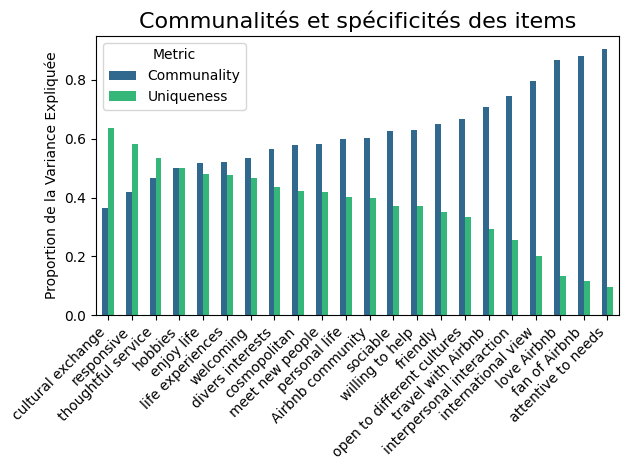

✅ [SAVE] barplot saved to ..\output_fa_all\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7824773113962931


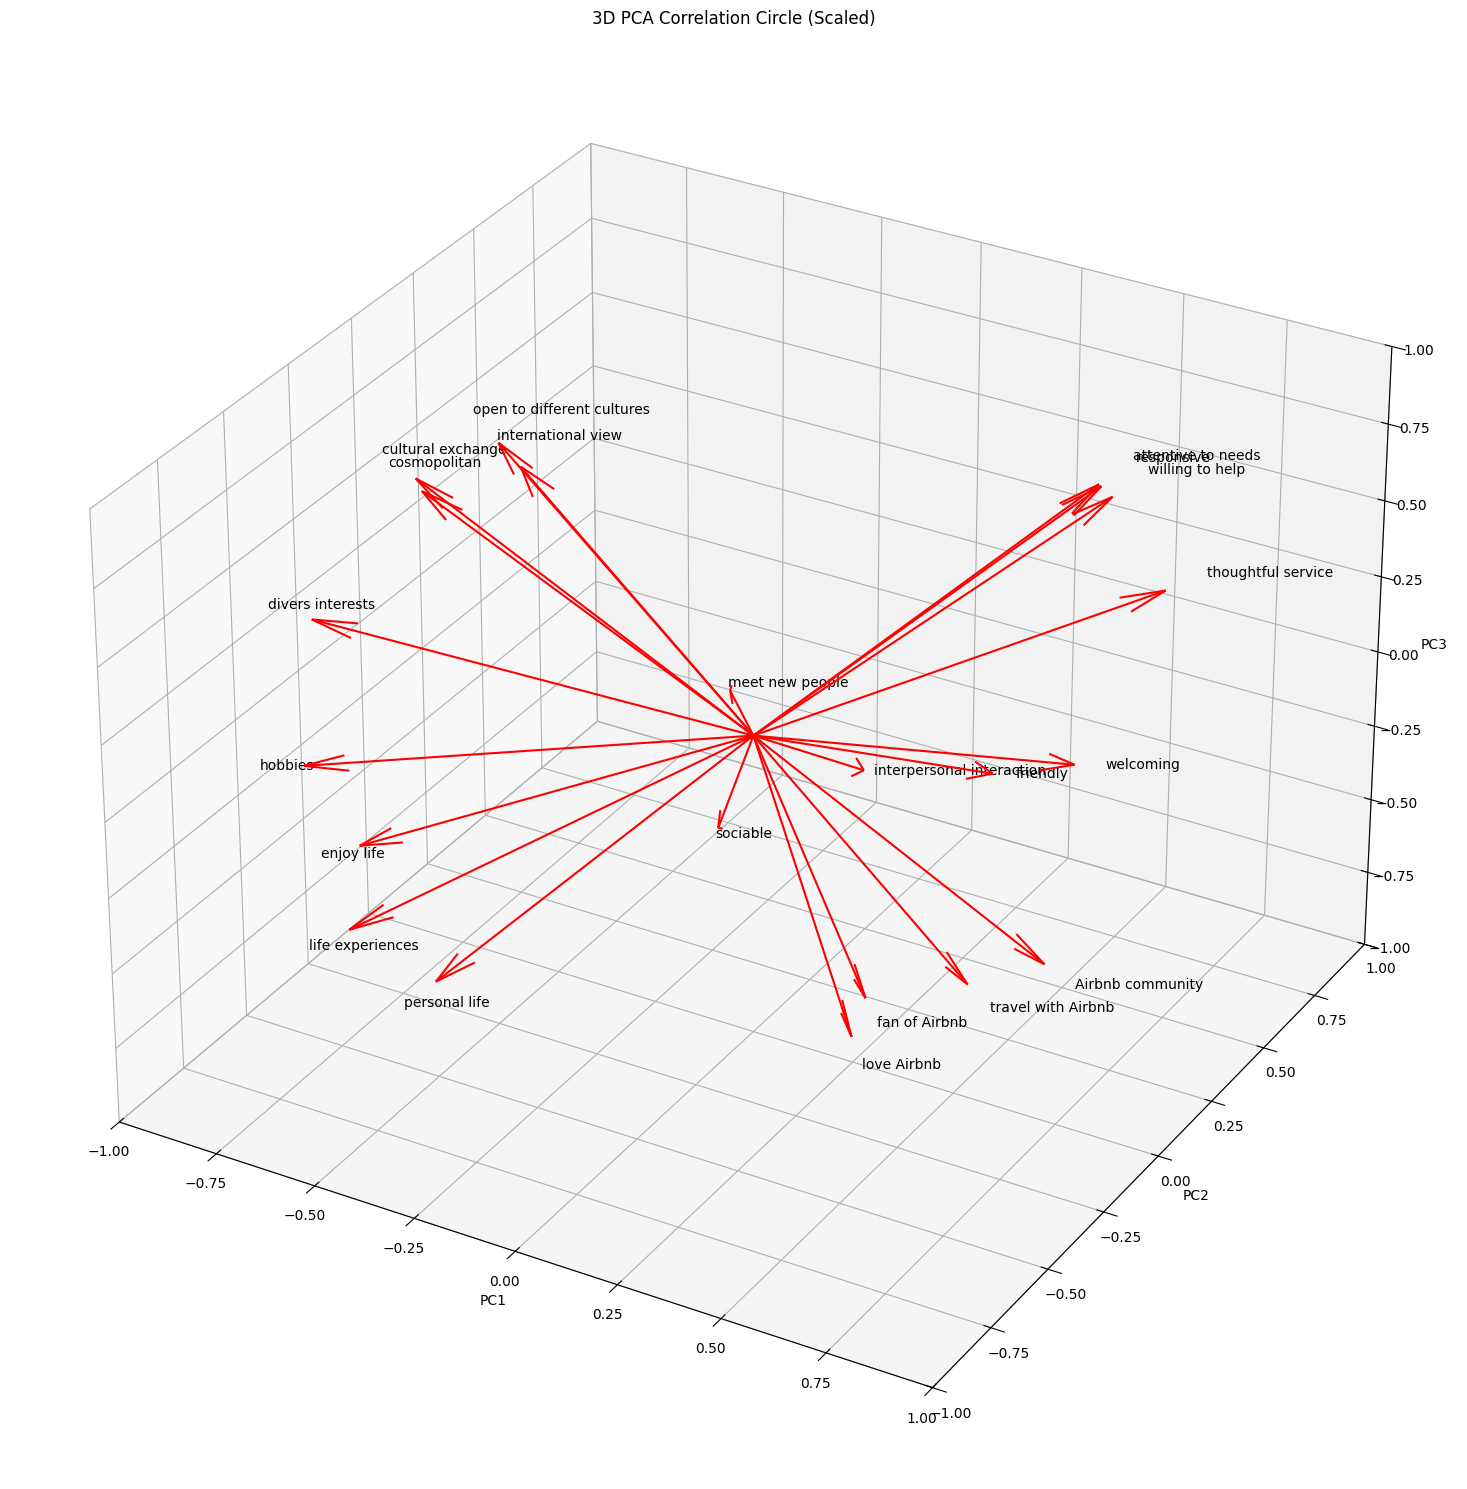

✅ [SAVE] PCA 3D saved to ..\output_fa_all\pca_3d.jpg!



In [6]:
## 21/03/26

importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all")
OUTPUT_FOLDER_DATA=Path("../data_processed")


listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","authenticité","auto_promotion","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:38: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df_items)


[INFO] df_items : 62738 rows!
[INFO] all output saved to '..\output_fa_paris'!
df with fa scores saved to '..\data_processed_paris' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:26659

[INFO] kmo_model score (> 0.7) :0.8708486940515002

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


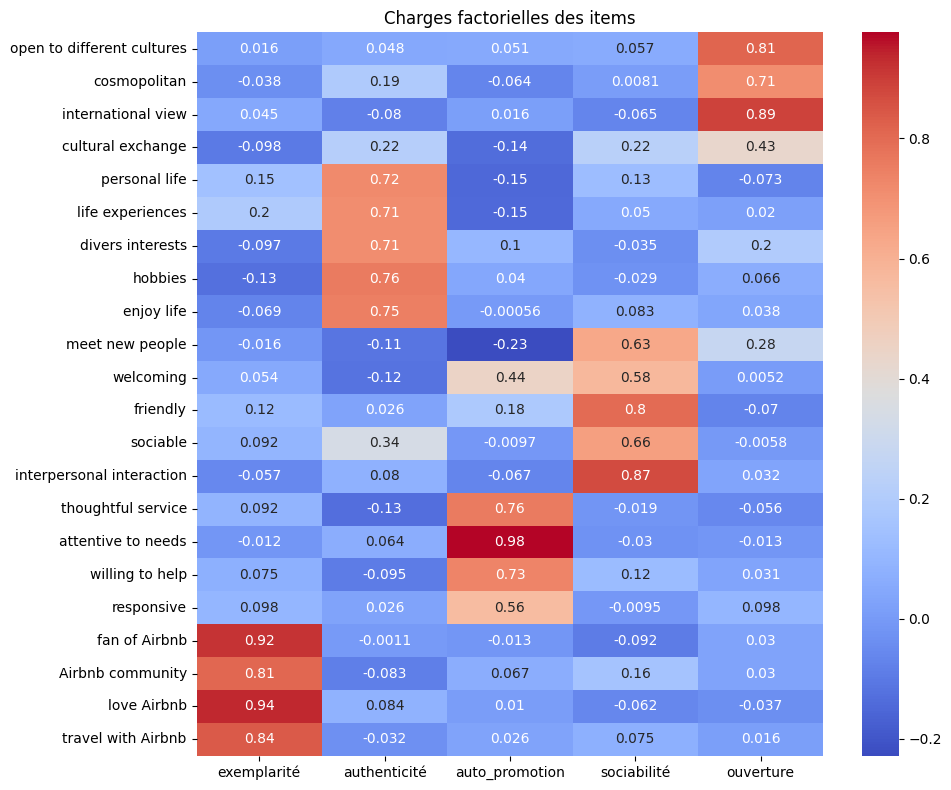

✅ [SAVE] heatmap of items saved to ..\output_fa_paris\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6337813802147857
[INFO] mean UNIQ : 0.3662186197852144

[WARNING] 2/22 low communality items (< 0.5):
cultural exchange;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_paris\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(26659, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,0.500502,-0.155740
authenticité,0.762084,-0.237112
sociabilité,0.649953,0.420401
auto_promotion,-0.162250,0.773717
exemplarité,0.145026,0.580141


✅[SAVE] scores df saved to ..\output_fa_paris\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


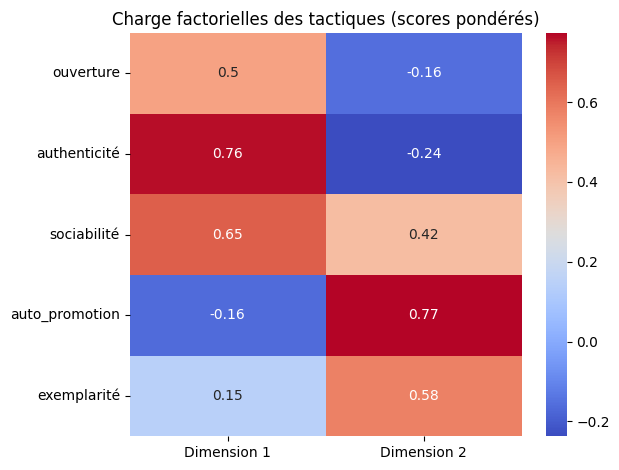

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_paris\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.414743,0.020158,0.004774,0.002003,0.003969,0.937983,-0.718933,0.456366,0.429782,-0.656082
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.973139,0.285223,0.747109,0.138229,0.311270,0.661481,0.129416,1.020174,1.323667,0.403382
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.379953,0.000320,0.000885,0.000308,0.001216,-1.092785,-0.678477,-1.769704,-1.527649,-0.761794
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.332744,0.007621,0.024031,0.009003,0.022716,0.979259,1.226686,0.657466,-1.618696,-0.695859


[INFO] scores shape (len(data), 1/2*n_factors) :(26659, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 26659, 26659, 26659
len(DF)==len(listings_tactics):62738,62738

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed_paris\listings_paris2406_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.843758
1,authenticité,0.878117
2,sociabilité,0.858820
3,auto_promotion,0.862768
4,exemplarité,0.934563


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_paris\cronbachs_alpha.csv!



In [ ]:
## 31/01/26
importlib.reload(fa)
from utils.fa import run_fa

INPUT_FOLDER_DATA=Path("../data_processed_paris")
path_df_items=INPUT_FOLDER_DATA/"listings_paris2406_bge_items.csv"

OUTPUT_FOLDER=Path("../output_fa_paris")
OUTPUT_FOLDER_DATA=Path("../data_processed_paris")


run_fa(path_df_items=path_df_items, items=LABELS_EN, 
       output_folder=OUTPUT_FOLDER,
        output_folder_data=OUTPUT_FOLDER_DATA,
        n_factors=5, rotation="oblimin",
        fa_names=["exemplarité","authenticité", "auto_promotion","sociabilité","ouverture"],#check order!!
        dict_factor_items=DICT_FACTOR_ITEMS,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        ndigits=4)



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:38: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df_items)


[INFO] df_items : 62738 rows!
[INFO] all output saved to '..\output_fa_paris'!
df with fa scores saved to '..\data_processed_paris' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:26659

[INFO] kmo_model score (> 0.7) :0.8708486940515002

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


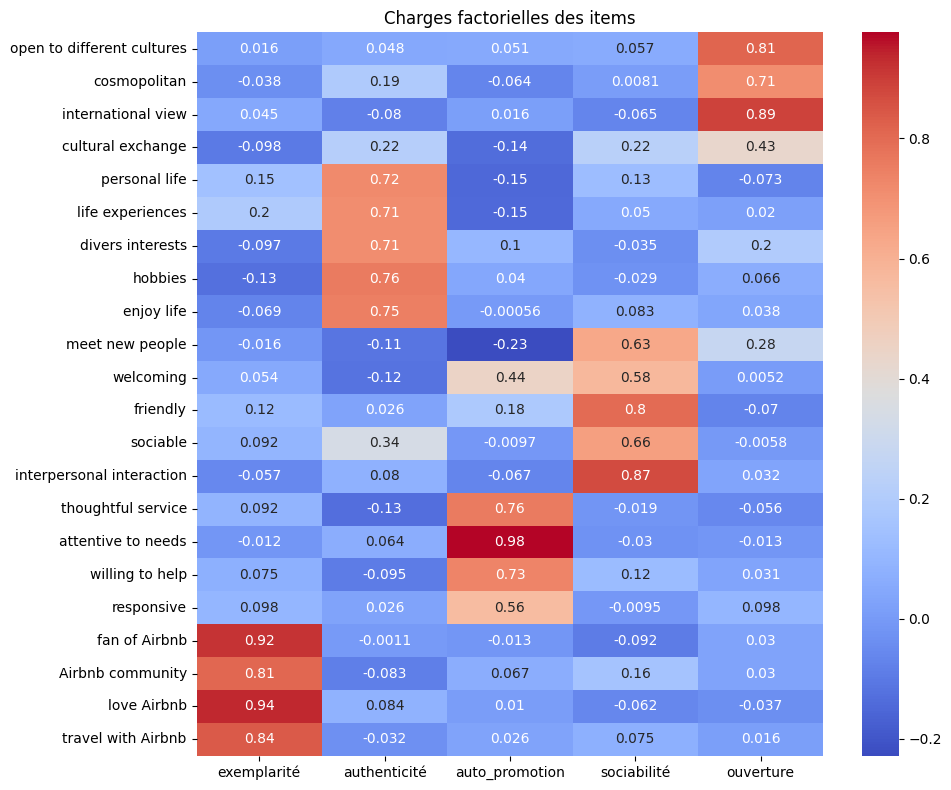

✅ [SAVE] heatmap of items saved to ..\output_fa_paris\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6337813802147857
[INFO] mean UNIQ : 0.3662186197852144

[WARNING] 2/22 low communality items (< 0.5):
cultural exchange;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_paris\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(26659, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,0.500502,-0.155740
authenticité,0.762084,-0.237112
sociabilité,0.649953,0.420401
auto_promotion,-0.162250,0.773717
exemplarité,0.145026,0.580141


✅[SAVE] scores df saved to ..\output_fa_paris\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


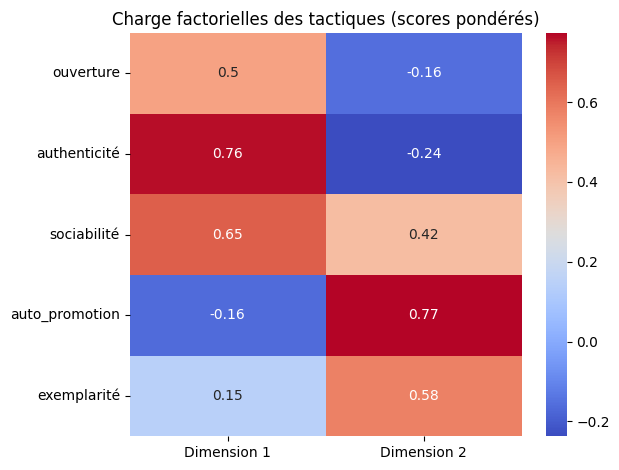

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_paris\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.414743,0.020158,0.004774,0.002003,0.003969,0.937983,-0.718933,0.456366,0.429782,-0.656082
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.973139,0.285223,0.747109,0.138229,0.311270,0.661481,0.129416,1.020174,1.323667,0.403382
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.379953,0.000320,0.000885,0.000308,0.001216,-1.092785,-0.678477,-1.769704,-1.527649,-0.761794
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.332744,0.007621,0.024031,0.009003,0.022716,0.979259,1.226686,0.657466,-1.618696,-0.695859


[INFO] scores shape (len(data), 1/2*n_factors) :(26659, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 26659, 26659, 26659
len(DF)==len(listings_tactics):62738,62738

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed_paris\listings_paris2406_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.843758
1,authenticité,0.878117
2,sociabilité,0.858820
3,auto_promotion,0.862768
4,exemplarité,0.934563


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_paris\cronbachs_alpha.csv!



In [ ]:
# importlib.reload(fa)
# from utils.fa import run_fa

# INPUT_FOLDER_DATA=Path("../data_processed_paris")
# path_df_items=INPUT_FOLDER_DATA/"listings_paris2406_bge_items.csv"

# OUTPUT_FOLDER=Path("../output_fa_paris")
# OUTPUT_FOLDER_DATA=Path("../data_processed_paris")


# run_fa(path_df_items=path_df_items, items=LABELS_EN, 
#        output_folder=OUTPUT_FOLDER,
#         output_folder_data=OUTPUT_FOLDER_DATA,
#         n_factors=5, rotation="oblimin",
#         fa_names=["exemplarité","authenticité", "auto_promotion","sociabilité","ouverture"],#check order!!
#         dict_factor_items=DICT_FACTOR_ITEMS,
#         get_items_heatmap=True,
#         get_items_table=True, low_comm_t=0.5,
#         get_factor_scores_by='weighted',
#         run_fa_on_scores="weighted",
#         get_scores_heatmap=True,
#         get_cronbachs_a=True,
#         get_barplot=False, get_pca3d=False, 
#         ndigits=4)

[INFO] df_items : 49856 rows!
[INFO] all output saved to '..\output_fa_london'!
df with fa scores saved to '..\data_processed_london' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:26046

[INFO] kmo_model score (> 0.7) :0.8731309199725604

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


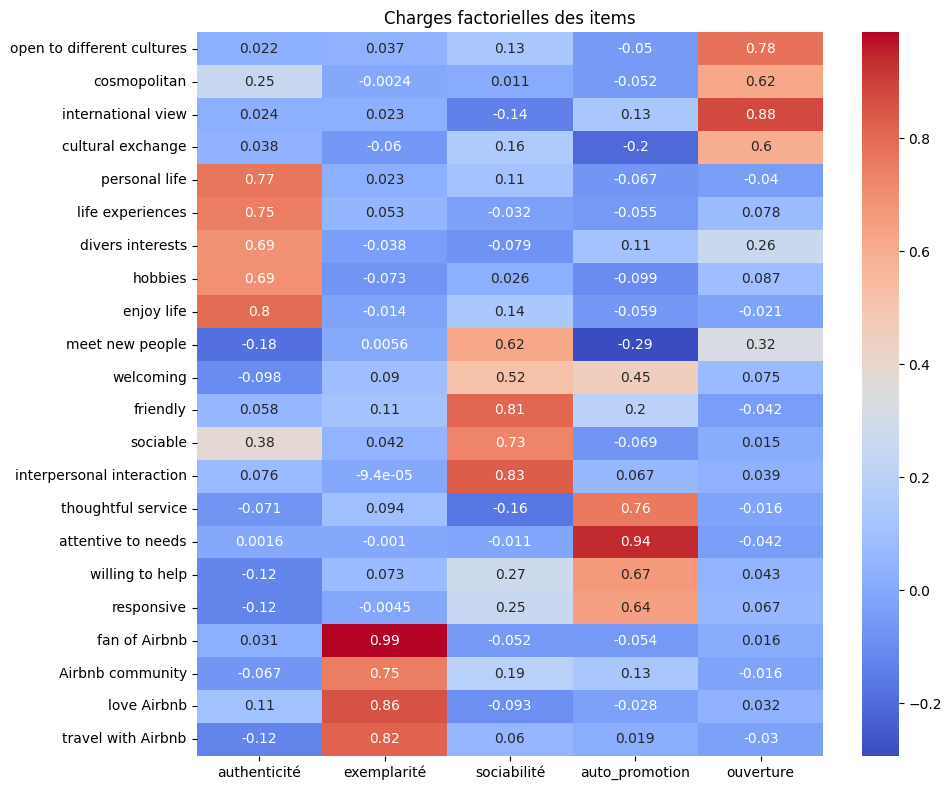

✅ [SAVE] heatmap of items saved to ..\output_fa_london\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_london\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6384694618159338
[INFO] mean UNIQ : 0.36153053818406616

[WARNING] 4/22 low communality items (< 0.5):
cosmopolitan;cultural exchange;welcoming;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_london\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_london\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(26046, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,-0.015294,0.620661
authenticité,-0.323603,0.677448
sociabilité,0.412188,0.582296
auto_promotion,0.848336,-0.102735
exemplarité,0.496891,0.209042


✅[SAVE] scores df saved to ..\output_fa_london\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_london\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


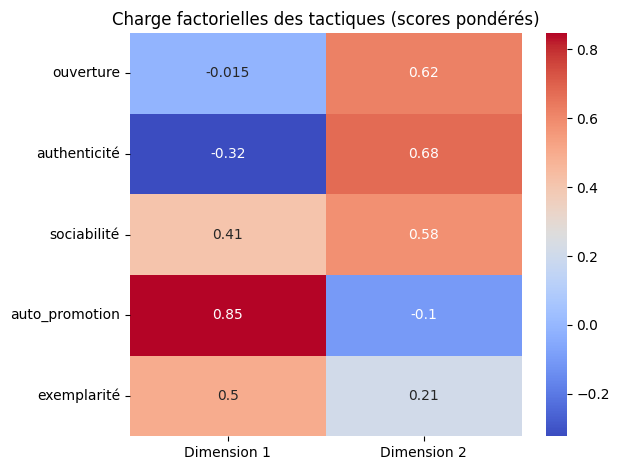

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_london\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,1126718007114818431,https://www.airbnb.com/rooms/1126718007114818431,20240614004129,2024-06-14,city scrape,Cozy house in Northolt,Located 1 minute away from a bus stop and 10 m...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,380326752,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,702589406864297985,https://www.airbnb.com/rooms/702589406864297985,20240614004129,2024-06-15,city scrape,Up in the sky in London!,"One bedroom with double bed, desk and with th...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,77760754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,904867371314200140,https://www.airbnb.com/rooms/904867371314200140,20240614004129,2024-06-14,city scrape,"Free Parking: Luxury, Comfy, Near Airport, Net...",Delight in elegance near Heathrow. Sink into t...,Located near Heathrow Airport and West Drayton...,https://a0.muscache.com/pictures/miso/Hosting-...,517837625,...,0.596389,0.166201,0.805479,0.173218,0.350394,-0.829890,-0.555946,-0.646149,0.815285,0.232179
3,809481748064671711,https://www.airbnb.com/rooms/809481748064671711,20240614004129,2024-06-15,city scrape,4 min walk from the station 1 bedroom apartment,This indipendent apartment has a style. Well ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,30949469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5570655,https://www.airbnb.com/rooms/5570655,20240614004129,2024-06-15,city scrape,Fulham Garden Flat,Well decorated sunny garden flat in Fulham Par...,"Lovely, safe and quiet residential area with s...",https://a0.muscache.com/pictures/263d22a3-748e...,28880140,...,0.351617,0.002314,0.019909,0.007475,0.001919,0.021314,1.374000,-0.496466,-1.298396,-0.663074


[INFO] scores shape (len(data), 1/2*n_factors) :(26046, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 26046, 26046, 26046
len(DF)==len(listings_tactics):49856,49856

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed_london\listings_london2406_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.848751
1,authenticité,0.894501
2,sociabilité,0.865854
3,auto_promotion,0.873659
4,exemplarité,0.910428


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_london\cronbachs_alpha.csv!



In [6]:
importlib.reload(fa)
from utils.fa import run_fa
path_df_items="../data_processed_london/listings_london2406_bge_items.csv"

OUTPUT_FOLDER=Path("../output_fa_london")
OUTPUT_FOLDER_DATA=Path("../data_processed_london")


run_fa(path_df_items=path_df_items, items=LABELS_EN, 
       output_folder=OUTPUT_FOLDER,
        output_folder_data=OUTPUT_FOLDER_DATA,
        n_factors=5, rotation="oblimin", 
        fa_names=["authenticité", "exemplarité", "sociabilité","auto_promotion","ouverture"],
        dict_factor_items=DICT_FACTOR_ITEMS,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        ndigits=4)

In [16]:
df_scores.shape

(62738, 128)

## df london_paris

In [23]:
import pandas as pd
# df_paris = pd.read_csv("../data_processed_paris/listings_paris2406_bge_scores.csv")
# df_london = pd.read_csv("../data_processed_london/listings_london2406_bge_scores.csv")
print(df_paris.shape,df_london.shape)

df_paris["city"] = "paris"
df_london["city"] = "london"

# 强制列对齐（非常重要）
# common_cols = set(df_paris.columns) & set(df_london.columns)
# df_paris = df_paris[sorted(common_cols)]
# df_london = df_london[sorted(common_cols)]
# print(df_paris.shape,df_london.shape)

df_all = pd.concat([df_paris, df_london], ignore_index=True)
print(df_all.shape)
display(df_all.head())
df_all.to_csv("../data_all/listings_paris_london2406.csv", index=False)


(62738, 129) (49856, 129)
(112594, 129)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,city
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,paris
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.020158,0.004774,0.002003,0.003969,0.937983,-0.718933,0.456366,0.429782,-0.656082,paris
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.285223,0.747109,0.138229,0.311270,0.661481,0.129416,1.020174,1.323667,0.403382,paris
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.000320,0.000885,0.000308,0.001216,-1.092785,-0.678477,-1.769704,-1.527649,-0.761794,paris
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.007621,0.024031,0.009003,0.022716,0.979259,1.226686,0.657466,-1.618696,-0.695859,paris


In [25]:
print(df_all[["authenticité","exemplarité","sociabilité",
        "auto_promotion","ouverture"]].describe(),'\n')
print(df_all["city"].value_counts())


       authenticité   exemplarité   sociabilité  auto_promotion     ouverture
count  5.270500e+04  5.270500e+04  5.270500e+04    5.270500e+04  5.270500e+04
mean  -8.169792e-17 -1.232884e-16 -5.284750e-17   -1.078520e-18 -2.210967e-17
std    9.492288e-01  9.754515e-01  9.599709e-01    9.687330e-01  9.397557e-01
min   -1.514683e+00 -8.962875e-01 -1.969192e+00   -2.149050e+00 -1.849169e+00
25%   -9.202213e-01 -6.688691e-01 -9.224995e-01   -8.882130e-01 -8.242538e-01
50%   -1.004003e-01 -5.087253e-01  1.566993e-01    2.408435e-01 -2.072376e-02
75%    8.742400e-01  3.166802e-01  8.636417e-01    8.681031e-01  7.625335e-01
max    1.987606e+00  2.702557e+00  1.733995e+00    1.496495e+00  2.014006e+00 

city
paris     62738
london    49856
Name: count, dtype: int64


## desc

In [43]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest

OUTPUT_FOLDER_DESC=Path("../output_fa_paris/desc")
# path_df_scores="../data_processed_paris\listings_paris2406_bge_scores.csv"
# df_scores=pd.read_csv(path_df_scores)
print(len(df_scores),"\n")
print(df_scores.columns.to_list())
print(df_scores.status.value_counts(dropna=False))


df_scores['is_new_enterant']=df_scores["status"].apply(lambda x : 1 if x=="new_host" or x=="reactived_host" else 0)

cols_to_check=[
    # "host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating",'number_of_reviews',
    "years_since_host", "professional_host",#'calculated_host_listings_count',
    # "lang", "len",
    "price", "availability_30","availability_90", "room_type", "instant_bookable",
    "number_of_reviews_thisQ", "number_of_reviews_nextQ",
    "booking_rate_l90d_previousQ", "booking_rate_l90d", #'is_changed'
]   
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]



62738 

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'a

In [ ]:
#变化/不变化房东，sp差异不大！booking90跳水！
#changed中存在很大的异质性，见下！

group_mean_table_ttest(df=df_scores, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



is_changed,0,1,ttest_p,significance
proportion,0.536214,0.463786,NaN,NaN
review_scores_rating,4.75575,4.789597,0.0,***
years_since_host,7.072679,6.563701,0.0,***
professional_host,0.39327,0.28759,0.0,***
price,255.019589,316.132144,0.0,***
availability_30,13.196159,8.730075,0.0,***
availability_90,53.205553,46.128329,0.0,***
number_of_reviews_thisQ,3.234803,3.138743,0.333688,
number_of_reviews_nextQ,2.703992,1.87033,0.0,***
booking_rate_l90d_previousQ,0.164845,0.159374,0.374961,


In [ ]:
## 新进入市场的3类房东 /旧房东（无论是否改变sp）
# 新进入房东关注处理auto外的sp

group_mean_table_ttest(df=df_scores, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='status_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


status_changed,0,1,ttest_p,significance
proportion,0.636281,0.363719,NaN,NaN
review_scores_rating,4.751397,4.806522,0.0,***
years_since_host,6.867632,6.782374,0.006845,**
professional_host,0.457526,0.146106,0.0,***
price,268.566547,309.246812,0.0,***
availability_30,13.200731,7.493361,0.0,***
availability_90,53.647085,43.408826,0.0,***
number_of_reviews_thisQ,3.460257,2.717911,0.0,***
number_of_reviews_nextQ,2.734212,1.588106,0.0,***
booking_rate_l90d_previousQ,0.164557,NaN,NaN,


In [ ]:
#分别观察三类
df_scores_new=df_scores[df_scores['status']=="new_host"]# new host, old_host changed sp, old_host didnt change sp 

group_mean_table_ttest(df=df_scores, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='status_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

In [ ]:
# 在所有旧房东中，是否修改sp的影响
# 显著加强auto，其余几乎都下降，exemplarite不变

df_scores_old=df_scores[df_scores['status']=="old_host"]# new host, old_host changed sp, old_host didnt change sp 

group_mean_table_ttest(df=df_scores_old, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='old_host_sp_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 39919 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



old_host_sp_changed,0,1,ttest_p,significance
proportion,0.842732,0.157268,NaN,NaN
review_scores_rating,4.75575,4.728076,0.0,***
years_since_host,7.072679,5.768875,0.0,***
professional_host,0.39327,0.801848,0.0,***
price,255.019589,341.158649,0.0,***
availability_30,13.196159,13.225231,0.833369,
availability_90,53.205553,56.013061,0.0,***
number_of_reviews_thisQ,3.234803,4.668366,0.0,***
number_of_reviews_nextQ,2.703992,2.896145,0.000826,***
booking_rate_l90d_previousQ,0.164845,0.159374,0.374961,


In [ ]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest

cols_to_check=[
    # "host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating",'number_of_reviews',
    "years_since_host", "professional_host",#'calculated_host_listings_count',
    # "lang", "len",
    "price", "availability_30","availability_90", "room_type", "instant_bookable",
    "number_of_reviews_thisQ", "number_of_reviews_nextQ",
    "booking_rate_l90d_previousQ", "booking_rate_l90d",'is_changed', 'city'
]   
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]



df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")
group_mean_table_ttest(df=df_all, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='city',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_26076\2337420157.py:18: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")


[CHECK] remove group_col 'city' from vars
[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :paris vs london
[INFO] ttest on 112594 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



city,paris,london,ttest_p,significance
proportion,0.557206,0.442794,NaN,NaN
review_scores_rating,4.771447,4.736833,0.0,***
years_since_host,6.836622,6.395379,0.0,***
professional_host,0.344257,0.620467,0.0,***
price,283.362731,211.021863,0.0,***
availability_30,11.124853,11.657955,0.0,***
availability_90,49.923236,50.273528,0.02785,*
number_of_reviews_thisQ,3.190252,4.766849,0.0,***
number_of_reviews_nextQ,2.317352,3.127447,0.0,***
booking_rate_l90d_previousQ,0.164557,0.100017,0.0,***


In [33]:
group_mean_table_ttest(df=df_all, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] remove group_col 'is_changed' from vars
[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 112594 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable; city



is_changed,0,1,ttest_p,significance
proportion,0.610494,0.389506,NaN,NaN
review_scores_rating,4.741307,4.779337,0.0,***
years_since_host,6.848133,6.316969,0.0,***
professional_host,0.508991,0.400059,0.0,***
price,235.293084,276.467097,0.0,***
availability_30,12.715994,9.237003,0.0,***
availability_90,52.498793,46.284636,0.0,***
number_of_reviews_thisQ,3.025968,5.240036,0.0,***
number_of_reviews_nextQ,2.823475,2.445002,0.0,***
booking_rate_l90d_previousQ,0.130936,0.14482,0.000663,***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26076\1451275193.py:4: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df_scores)


[INFO] groups of city:['paris' 'london']


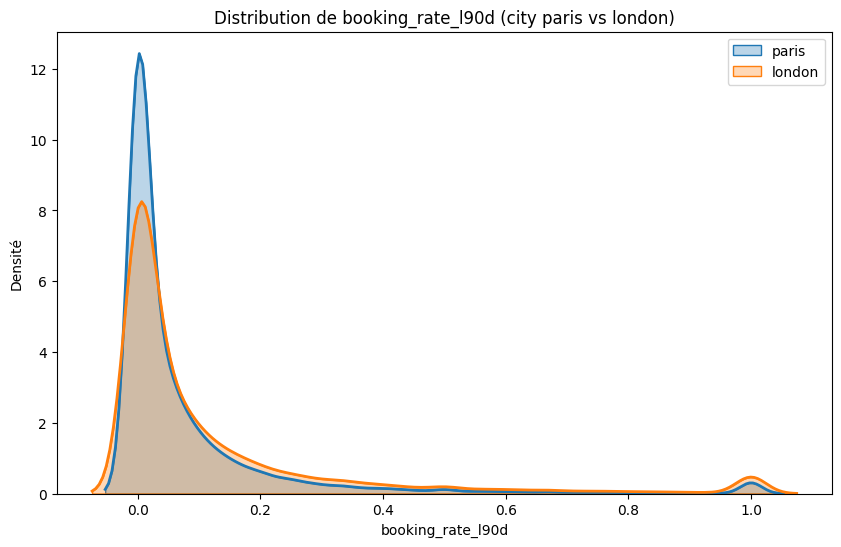

In [35]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_distribution
path_df_scores="../data_all\listings_paris_london2406.csv"
df=pd.read_csv(path_df_scores)
plot_distribution(df=df, group_col="city", y_var='booking_rate_l90d', 
                    save=False, output_folder=OUTPUT_FOLDER_DESC,filename=None)

## mod

In [ ]:
importlib.reload(modeling)
from utils.modeling import modeling_main, get_booking_rate_l30d


# INPUT_FOLDER_DATA=Path("../data_processed_paris/bge")
# INPUT_FOLDER_DATA/"listings_paris2406_scores_bge_reviews.csv"

#-------------------------------vars------------------------------------

y_var="booking_rate_l90d" #"availability_90" #"price" 
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', #"is_changed", #'calculated_host_listings_count',
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", 'is_within_1km',#"city"
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26076\1731833572.py:4: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_all\booking90-changed!


 ============================================basic model============================================= 

[CHECK] isna False in all 12 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  availability_90  room_type  instant_bookable  is_within_1km  city   booking_rate_l90d
False                   False                 False                 False             False              False              False            False      False             False          False  False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superho

,Basique,Tactiques,is_changed
is_changed,,,-0.0214***\n(0.0010)
ouverture,,-0.0015*\n(0.0009),-0.0010\n(0.0011)
authenticité,,0.0041***\n(0.0010),0.0051***\n(0.0012)
sociabilité,,0.0098***\n(0.0009),0.0103***\n(0.0011)
auto_promotion,,-0.0047***\n(0.0010),-0.0062***\n(0.0012)
exemplarité,,0.0042***\n(0.0008),0.0050***\n(0.0011)
is_changed:ouverture,,,-0.0010\n(0.0018)
is_changed:authenticité,,,-0.0032\n(0.0020)
is_changed:sociabilité,,,-0.0013\n(0.0018)
is_changed:auto_promotion,,,0.0039**\n(0.0019)


,Basique,Tactiques,is_changed
C(host_identity_verified)[T.t],0.0213***\n(0.0019),0.0193***\n(0.0019),0.0181***\n(0.0019)
C(host_has_profile_pic)[T.t],0.0070***\n(0.0024),0.0076***\n(0.0024),0.0064***\n(0.0024)
C(host_is_superhost)[T.t],0.0714***\n(0.0012),0.0698***\n(0.0012),0.0658***\n(0.0012)
C(room_type)[T.Hotel room],-0.0400***\n(0.0069),-0.0414***\n(0.0069),-0.0463***\n(0.0069)
C(room_type)[T.Private room],0.0284***\n(0.0013),0.0259***\n(0.0013),0.0248***\n(0.0013)
C(room_type)[T.Shared room],0.0352***\n(0.0077),0.0341***\n(0.0076),0.0320***\n(0.0076)
C(instant_bookable)[T.t],0.0145***\n(0.0012),0.0168***\n(0.0012),0.0167***\n(0.0012)
C(city)[T.paris],-0.0324***\n(0.0011),-0.0323***\n(0.0011),-0.0293***\n(0.0011)
review_scores_rating,0.0062***\n(0.0015),0.0058***\n(0.0015),0.0076***\n(0.0015)
years_since_host,-0.0016***\n(0.0001),-0.0017***\n(0.0001),-0.0019***\n(0.0001)


===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(room_type) + C(instant_bookable) + C(city) + review_scores_rating + years_since_host + professional_host + availability_90 + is_within_1km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:524: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if show and ax is None:


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(room_type) + C(instant_bookable) + C(city) + review_scores_rating + years_since_host + professional_host + availability_90 + is_within_1km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:524: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if show and ax is None:


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(room_type) + C(instant_bookable) + C(city) + review_scores_rating + years_since_host + professional_host + availability_90 + is_within_1km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:524: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if show and ax is None:


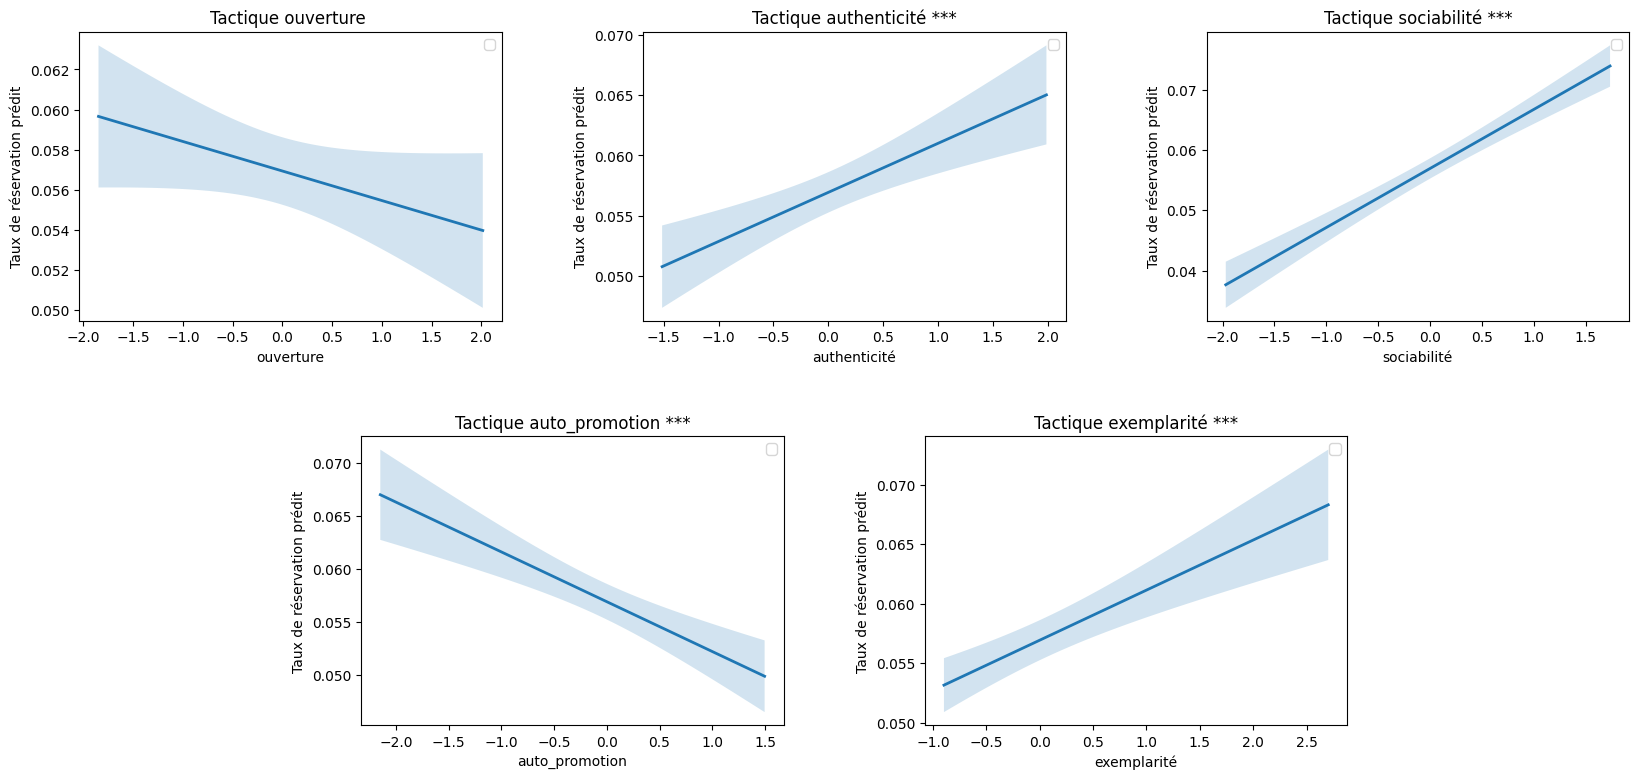

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(room_type) + C(instant_bookable) + C(city) + review_scores_rating + years_since_host + professional_host + availability_90 + is_within_1km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.00624054]; pval :0.000 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(room_type) + C(instant_bookable) + C(city) + review_scores_rating + years_since_host + professional_host + availability_90 + is_within_1km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [0.01477708]; pval :0.000 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(

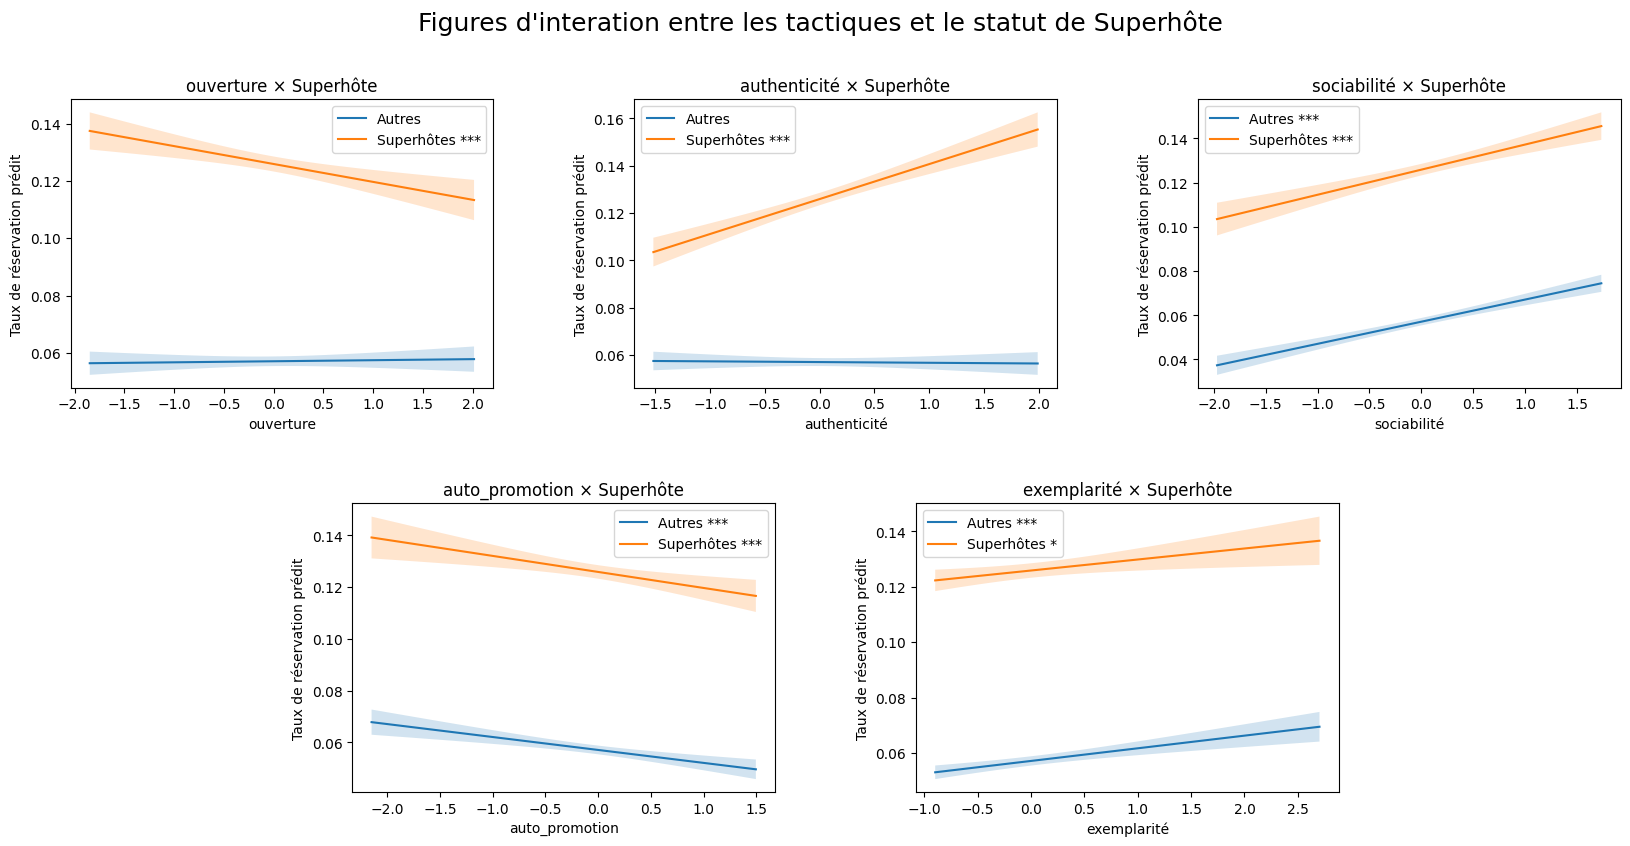

In [50]:
importlib.reload(modeling)
from utils.modeling import modeling_main
path_df="../data_all\listings_paris_london2406.csv"
df=pd.read_csv(path_df)

OUTPUT_FOLDER_MOD=Path("../output_mod_all/booking90-changed")

modeling_main(df_input=df, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="is_changed",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

In [38]:

OUTPUT_FOLDER_MOD=Path("../output_mod_all/booking90-city")

modeling_main(df_input=df, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="city",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_all\booking90-city!


 ============================================basic model============================================= 

[CHECK] isna False in all 14 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  lang   len    price  availability_90  room_type  instant_bookable  is_within_1km  city   booking_rate_l90d
False                   False                 False                 False             False              False  False  False  False            False      False             False          False  False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room

KeyError: 'C(city)[T.t]:ouverture'

C:\Users\yeliu\AppData\Local\Temp\ipykernel_26076\2322176583.py:5: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_paris\booking90-status!


 ============================================basic model============================================= 

[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  is_changed  lang   len    price  availability_90  room_type  instant_bookable  is_within_1km  booking_rate_l90d
False                   False                 False                 False             False              False              False       False  False  False  False            False      False             False          False                62738
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_ver

,is_base,coef,se,t,pval,sig
f,True,-0.003016,0.00132,-2.285075,0.022312,*
t,False,-0.008188,0.002181,-3.754453,0.000174,***


authenticité
x f/t


,is_base,coef,se,t,pval,sig
f,True,0.003139,0.001475,2.128635,0.033288,*
t,False,0.005957,0.002413,2.468754,0.013561,*


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:590: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + is_changed + len + price + availability_90 + is_within_1km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:590: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + is_changed + len + price + availability_90 + is_within_1km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:590: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


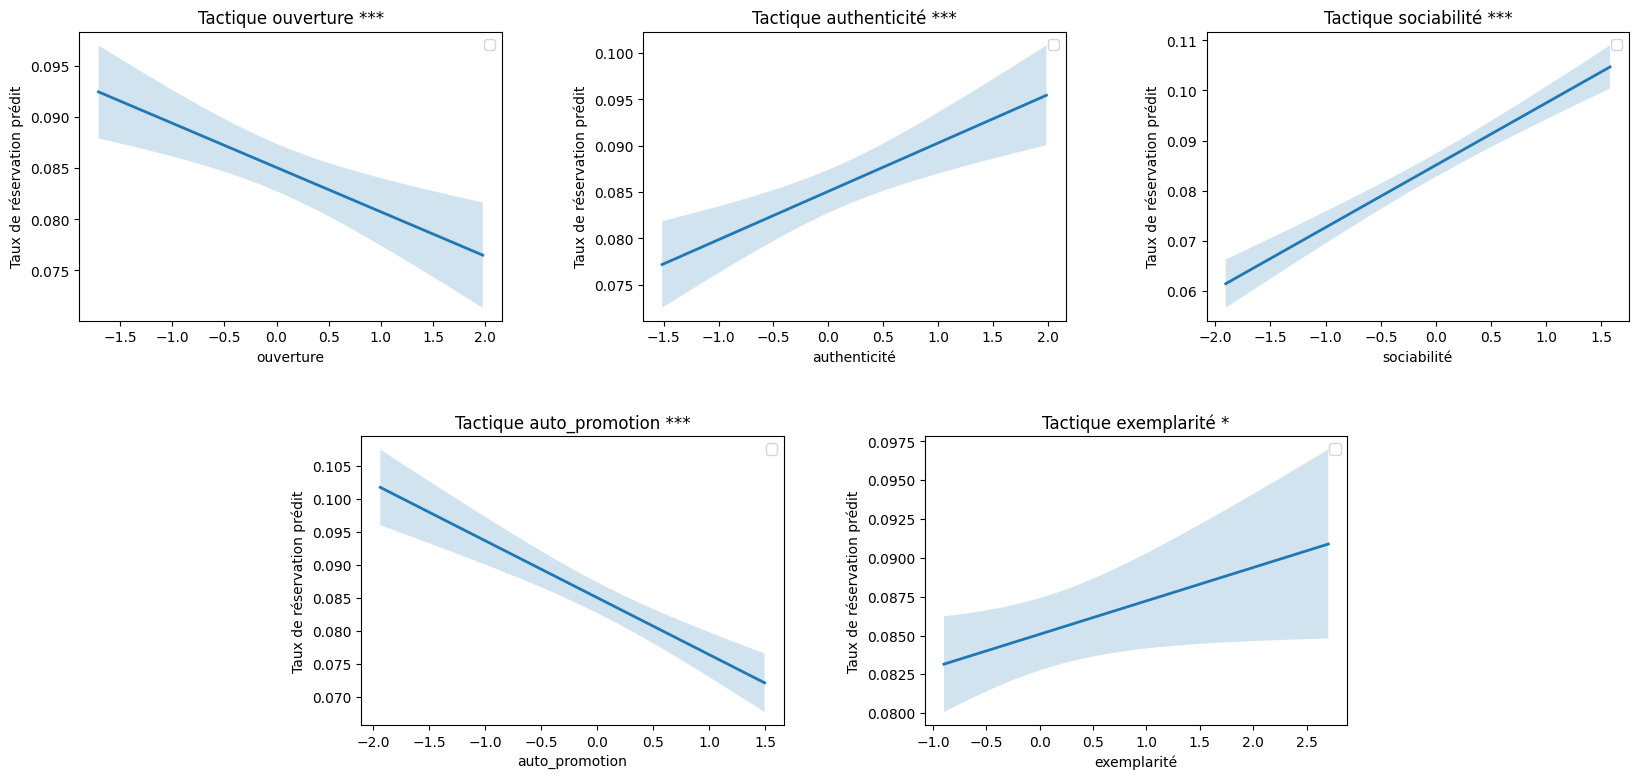

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + is_changed + len + price + availability_90 + is_within_1km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + is_changed + len + price + availability_90 + is_within_1km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + prof

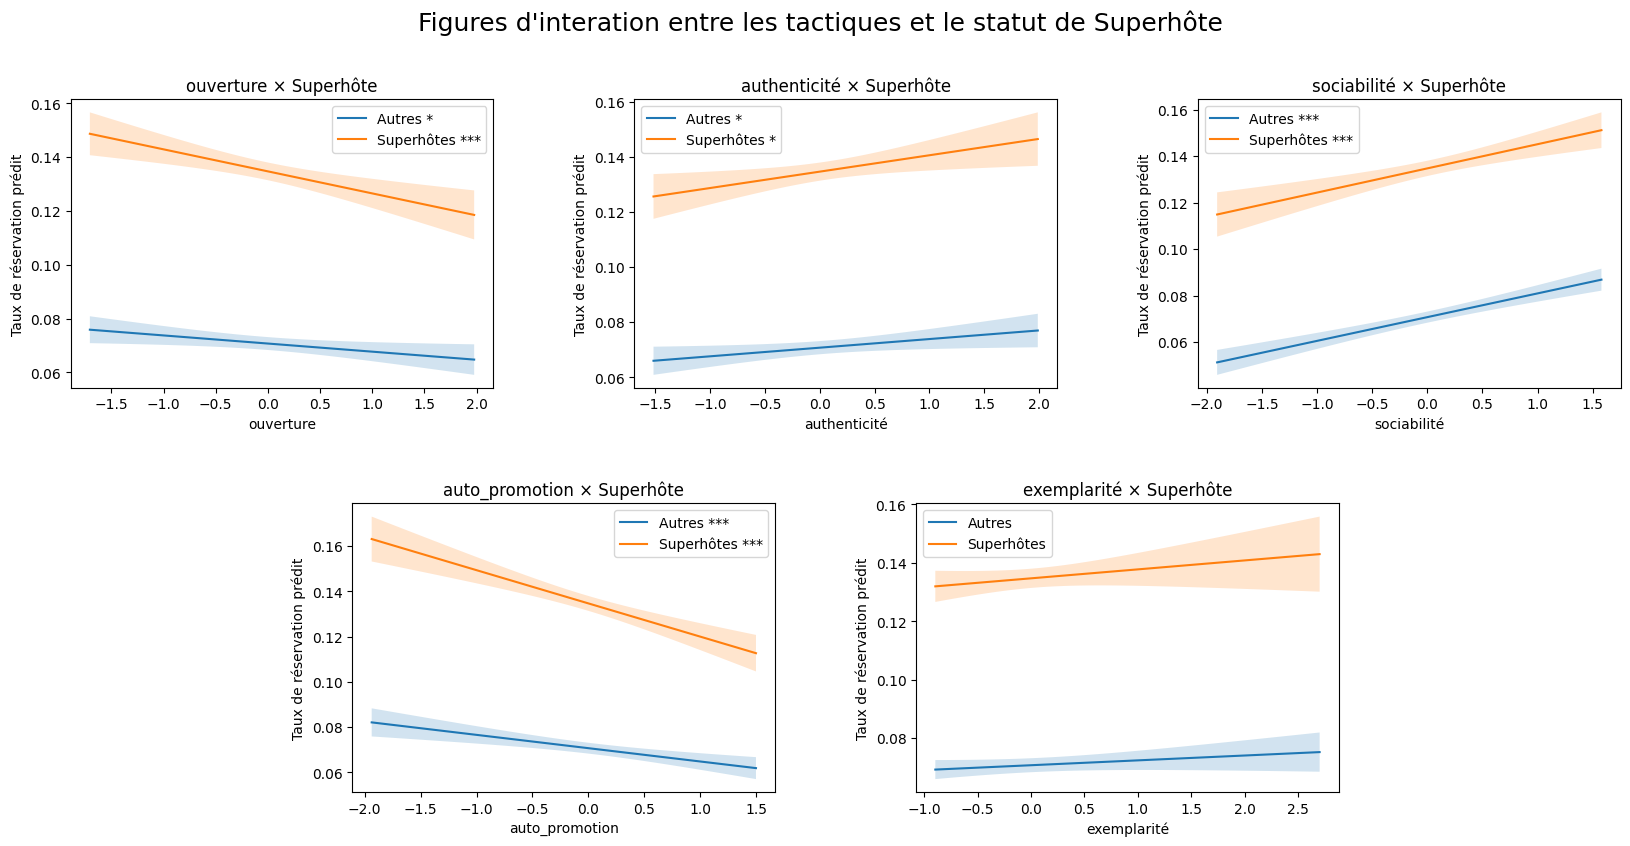

In [75]:
importlib.reload(modeling)
from utils.modeling import modeling_main
OUTPUT_FOLDER_MOD=Path("../output_mod_paris/booking90-status")

modeling_main(df_input=df, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="host_is_superhost",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

In [ ]:

path_df="../data_processed_paris\listings_london2406_bge_scores.csv"
df_london=pd.read_csv(path_df)

OUTPUT_FOLDER_MOD=Path("../output_mod_london/booking90-status")

modeling_main(df_input=df_london, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="status",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_london\booking90-changed!


 ============================================basic model============================================= 

[CHECK] isna False in all 14 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  is_changed  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False       False  False  False  False            False      False             False                49856
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_

,Basique,Tactiques,is_changed
is_changed,-0.0009\n(0.0018),-0.0011\n(0.0018),-0.0011\n(0.0018)
ouverture,,0.0013\n(0.0014),0.0018\n(0.0017)
authenticité,,0.0027*\n(0.0016),0.0030\n(0.0018)
sociabilité,,0.0103***\n(0.0014),0.0101***\n(0.0017)
auto_promotion,,-0.0018\n(0.0016),-0.0022\n(0.0019)
exemplarité,,0.0074***\n(0.0013),0.0071***\n(0.0015)
is_changed:ouverture,,,-0.0018\n(0.0031)
is_changed:authenticité,,,-0.0008\n(0.0034)
is_changed:sociabilité,,,0.0009\n(0.0030)
is_changed:auto_promotion,,,0.0015\n(0.0033)


,Basique,Tactiques,is_changed
C(host_identity_verified)[T.t],0.0230***\n(0.0031),0.0208***\n(0.0032),0.0208***\n(0.0032)
C(host_has_profile_pic)[T.t],0.0062\n(0.0041),0.0070*\n(0.0040),0.0069*\n(0.0040)
C(host_is_superhost)[T.t],0.0638***\n(0.0020),0.0621***\n(0.0020),0.0620***\n(0.0020)
C(lang)[T.fr],0.0260\n(0.0219),0.0371*\n(0.0219),0.0372*\n(0.0219)
C(lang)[T.no_text],-0.0035*\n(0.0020),-0.0044**\n(0.0021),-0.0043**\n(0.0021)
C(lang)[T.other_langs],0.0083\n(0.0085),0.0090\n(0.0085),0.0090\n(0.0085)
C(room_type)[T.Hotel room],-0.0158\n(0.0166),-0.0118\n(0.0166),-0.0117\n(0.0166)
C(room_type)[T.Private room],0.0374***\n(0.0018),0.0350***\n(0.0018),0.0349***\n(0.0018)
C(room_type)[T.Shared room],0.0516***\n(0.0119),0.0518***\n(0.0119),0.0519***\n(0.0119)
C(instant_bookable)[T.t],0.0037*\n(0.0019),0.0057***\n(0.0019),0.0056***\n(0.0019)


===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


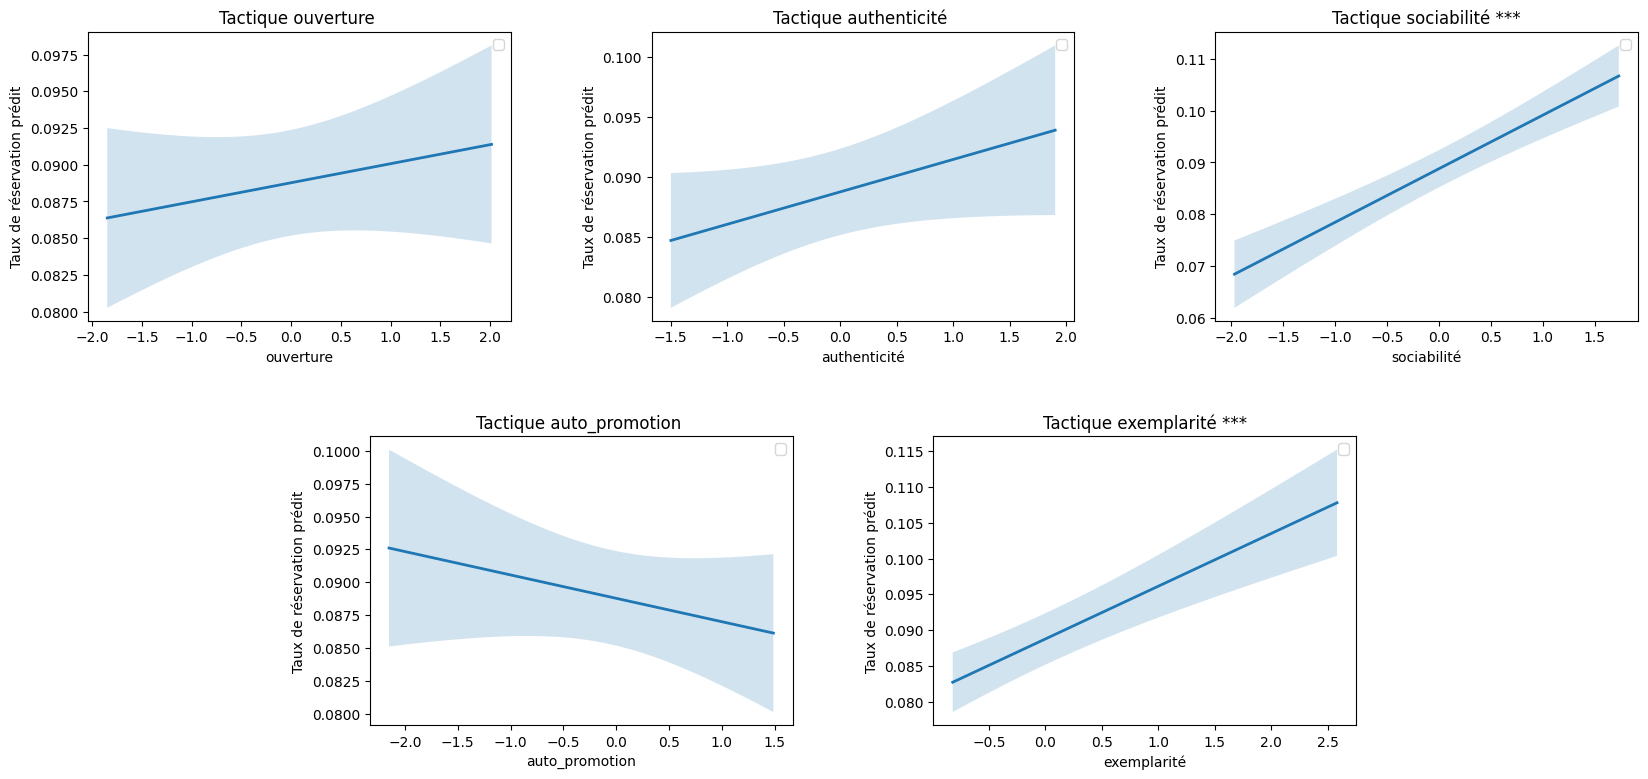

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.00284771]; pval :0.257 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [0.0184296]; pval :0.000 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang)

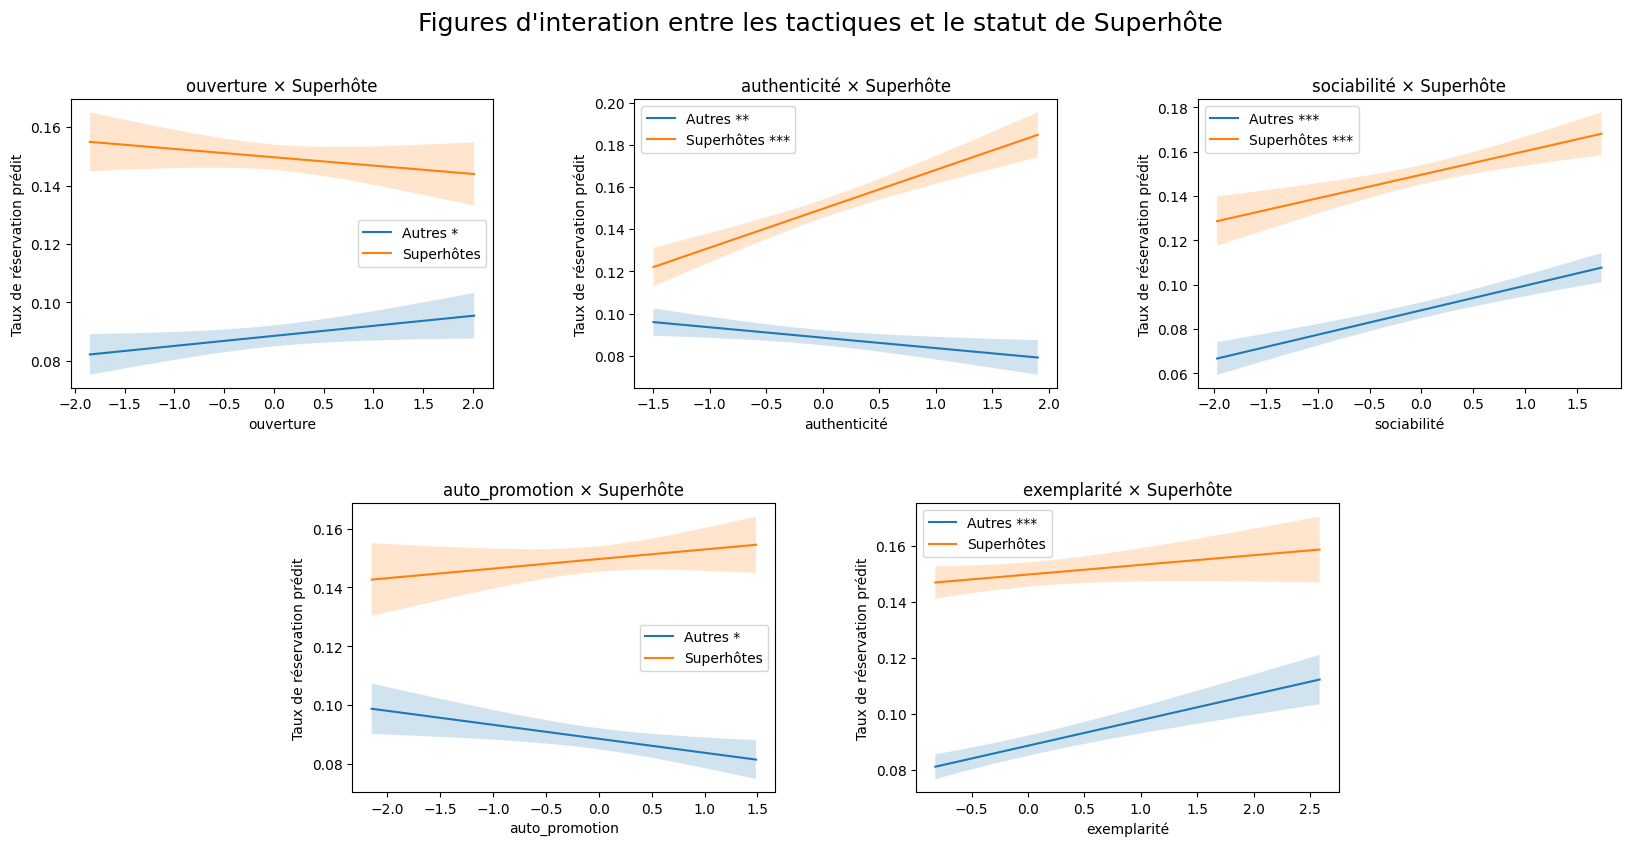

In [29]:
importlib.reload(modeling)
from utils.modeling import modeling_main

y_var="booking_rate_l90d" #"availability_90" #"price" 
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', 'is_changed', #'calculated_host_listings_count',
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
group_col="host_is_superhost"

#-------------------------------------------------------------------
path_df="../data_processed_london\listings_london2406_bge_scores.csv"
df=pd.read_csv(path_df)

OUTPUT_FOLDER_MOD=Path("../output_mod_london/booking90-changed")

modeling_main(df_input=df, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="is_changed",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_bge\booking90-superhost!


 ============================================basic model============================================= 

[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  lang   len    price  availability_90  room_type  instant_bookable  is_within_3km  booking_rate_l90d
False                   False                 False                 False             False              False  False  False  False            False      False             False          False                62738
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],,,0.0718***\n(0.0015)
ouverture,,-0.0054***\n(0.0012),-0.0040***\n(0.0013)
C(host_is_superhost)[T.t]:ouverture,,,-0.0042*\n(0.0025)
authenticité,,0.0057***\n(0.0013),0.0031**\n(0.0015)
C(host_is_superhost)[T.t]:authenticité,,,0.0037\n(0.0028)
sociabilité,,0.0133***\n(0.0012),0.0107***\n(0.0013)
C(host_is_superhost)[T.t]:sociabilité,,,-0.0004\n(0.0027)
auto_promotion,,-0.0094***\n(0.0013),-0.0065***\n(0.0015)
C(host_is_superhost)[T.t]:auto_promotion,,,-0.0087***\n(0.0028)
exemplarité,,0.0015\n(0.0011),0.0010\n(0.0012)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.0272***\n(0.0024),0.0239***\n(0.0024),0.0154***\n(0.0023)
C(host_has_profile_pic)[T.t],0.0071**\n(0.0030),0.0079***\n(0.0030),0.0039\n(0.0029)
C(lang)[T.fr],0.0092***\n(0.0019),0.0047**\n(0.0021),0.0060***\n(0.0020)
C(lang)[T.no_text],-0.0003\n(0.0019),0.0009\n(0.0021),0.0045**\n(0.0020)
C(lang)[T.other_langs],0.0129**\n(0.0062),0.0137**\n(0.0062),0.0121**\n(0.0061)
C(room_type)[T.Hotel room],-0.0538***\n(0.0070),-0.0587***\n(0.0070),-0.0614***\n(0.0069)
C(room_type)[T.Private room],0.0229***\n(0.0022),0.0201***\n(0.0022),0.0168***\n(0.0022)
C(room_type)[T.Shared room],0.0235**\n(0.0099),0.0188*\n(0.0099),0.0213**\n(0.0097)
C(instant_bookable)[T.t],0.0207***\n(0.0015),0.0236***\n(0.0016),0.0232***\n(0.0015)
review_scores_rating,0.0183***\n(0.0020),0.0168***\n(0.0020),0.0030\n(0.0020)


===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90 + is_within_3km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90 + is_within_3km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90 + is_within_3km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


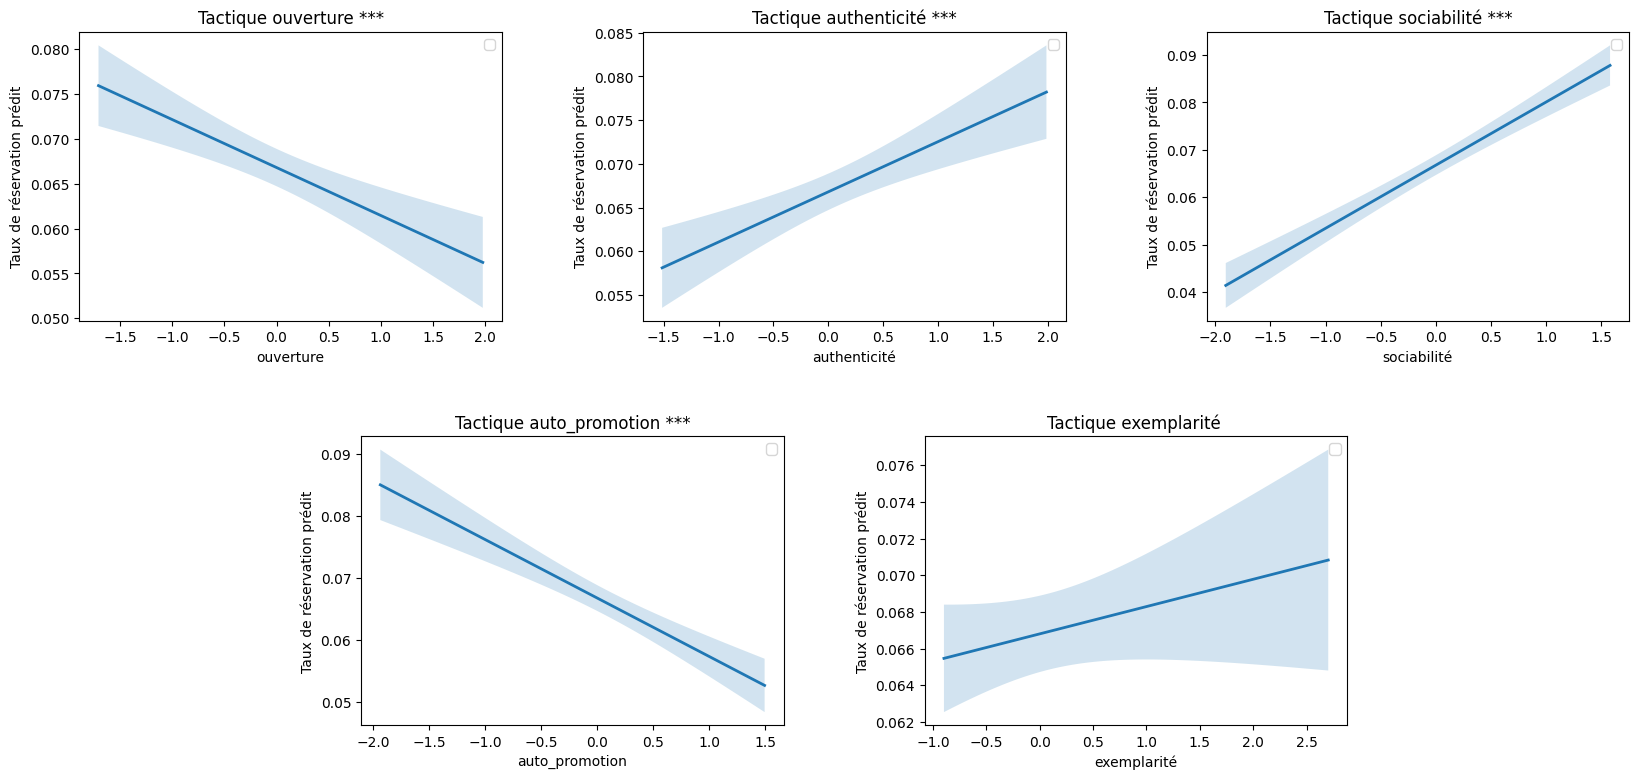

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90 + is_within_3km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.00820264]; pval :0.000 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90 + is_within_3km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [0.00681437]; pval :0.005 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + 

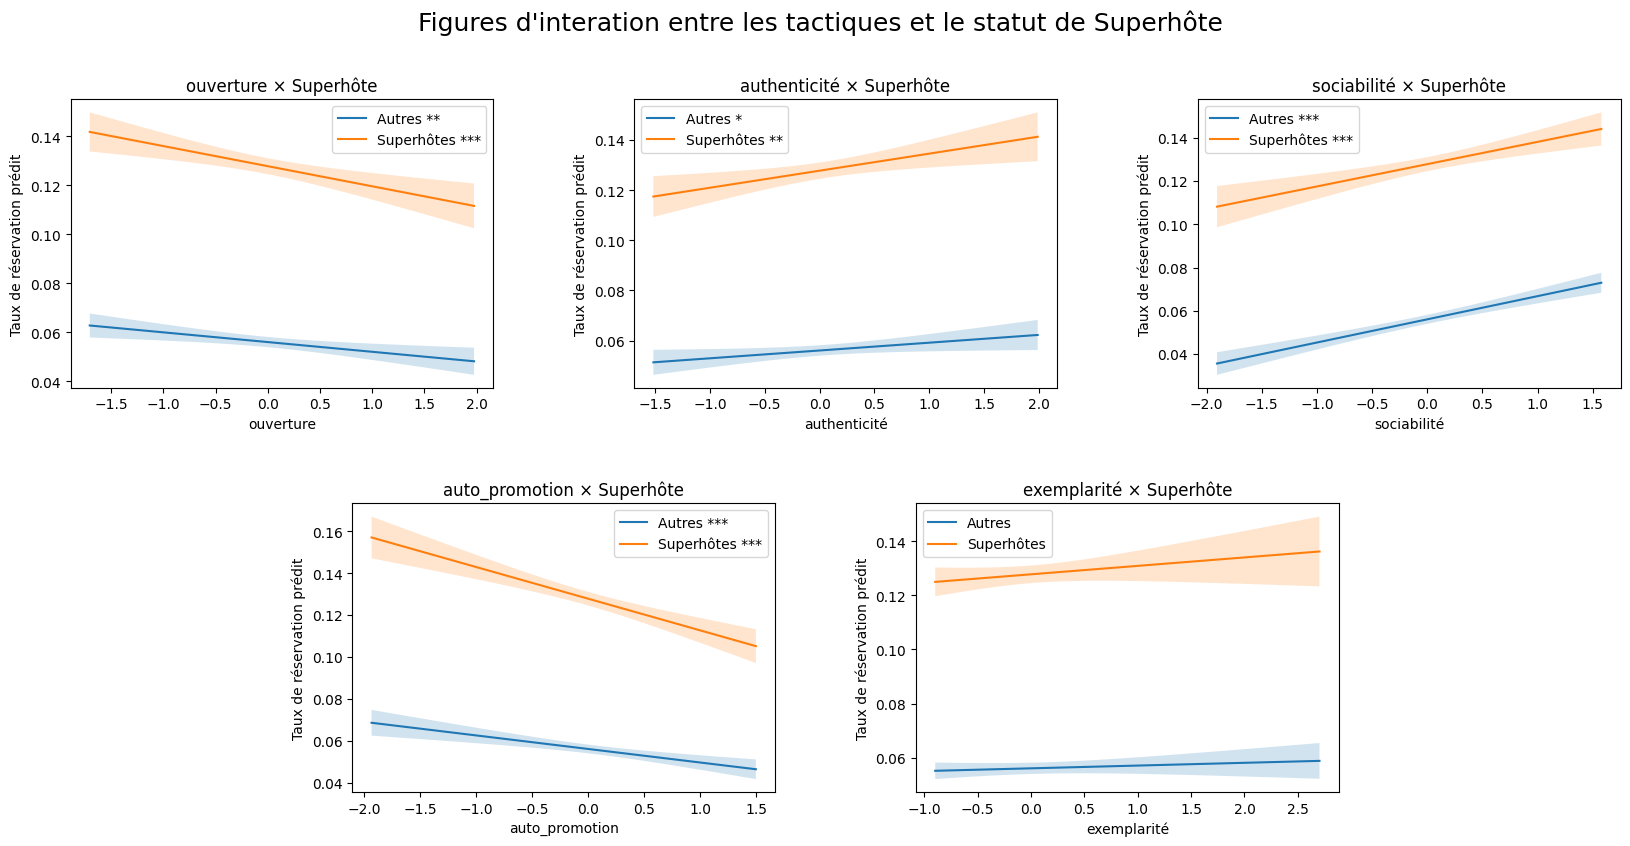

In [40]:
importlib.reload(modeling)
from utils.modeling import modeling_main

OUTPUT_FOLDER_MOD=Path("../output_mod_bge/booking90-superhost")

modeling_main(df_input=df_reviews, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="host_is_superhost",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_bge\booking90-pro!


 ============================================basic model============================================= 

[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  lang   len    price  availability_90  room_type  instant_bookable  is_within_3km  booking_rate_l90d
False                   False                 False                 False             False              False  False  False  False            False      False             False          False                62738
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(insta

,Basique,Tactiques,x Superhôte
professional_host,0.0158***\n(0.0014),0.0193***\n(0.0015),0.0191***\n(0.0015)
ouverture,,-0.0054***\n(0.0012),-0.0033**\n(0.0015)
authenticité,,0.0057***\n(0.0013),0.0024\n(0.0016)
sociabilité,,0.0133***\n(0.0012),0.0057***\n(0.0015)
auto_promotion,,-0.0094***\n(0.0013),-0.0023\n(0.0017)
exemplarité,,0.0015\n(0.0011),-0.0011\n(0.0015)
professional_host:ouverture,,,-0.0042*\n(0.0022)
professional_host:authenticité,,,0.0063**\n(0.0027)
professional_host:sociabilité,,,0.0149***\n(0.0024)
professional_host:auto_promotion,,,-0.0142***\n(0.0026)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.0272***\n(0.0024),0.0239***\n(0.0024),0.0225***\n(0.0024)
C(host_has_profile_pic)[T.t],0.0071**\n(0.0030),0.0079***\n(0.0030),0.0080***\n(0.0030)
C(lang)[T.fr],0.0092***\n(0.0019),0.0047**\n(0.0021),0.0059***\n(0.0021)
C(lang)[T.no_text],-0.0003\n(0.0019),0.0009\n(0.0021),-0.0006\n(0.0021)
C(lang)[T.other_langs],0.0129**\n(0.0062),0.0137**\n(0.0062),0.0114*\n(0.0062)
C(room_type)[T.Hotel room],-0.0538***\n(0.0070),-0.0587***\n(0.0070),-0.0615***\n(0.0070)
C(room_type)[T.Private room],0.0229***\n(0.0022),0.0201***\n(0.0022),0.0188***\n(0.0022)
C(room_type)[T.Shared room],0.0235**\n(0.0099),0.0188*\n(0.0099),0.0175*\n(0.0099)
C(instant_bookable)[T.t],0.0207***\n(0.0015),0.0236***\n(0.0016),0.0238***\n(0.0016)
review_scores_rating,0.0183***\n(0.0020),0.0168***\n(0.0020),0.0171***\n(0.0020)


===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + len + price + availability_90 + is_within_3km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + len + price + availability_90 + is_within_3km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + len + price + availability_90 + is_within_3km+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return fig, ax


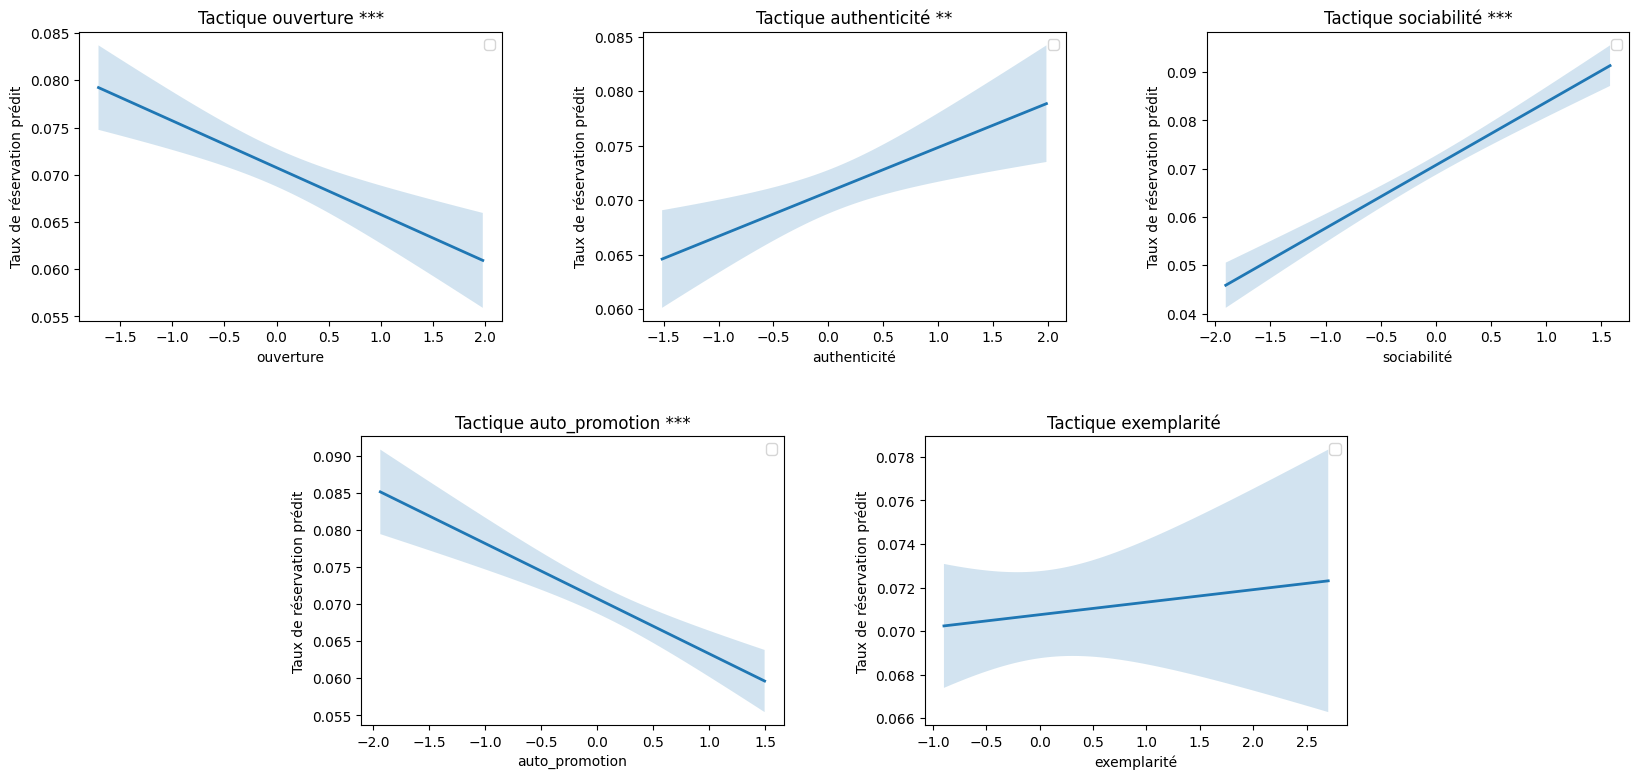

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + len + price + availability_90 + is_within_3km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.00810356]; pval :0.000 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + len + price + availability_90 + is_within_3km+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [0.00572169]; pval :0.018 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(ro

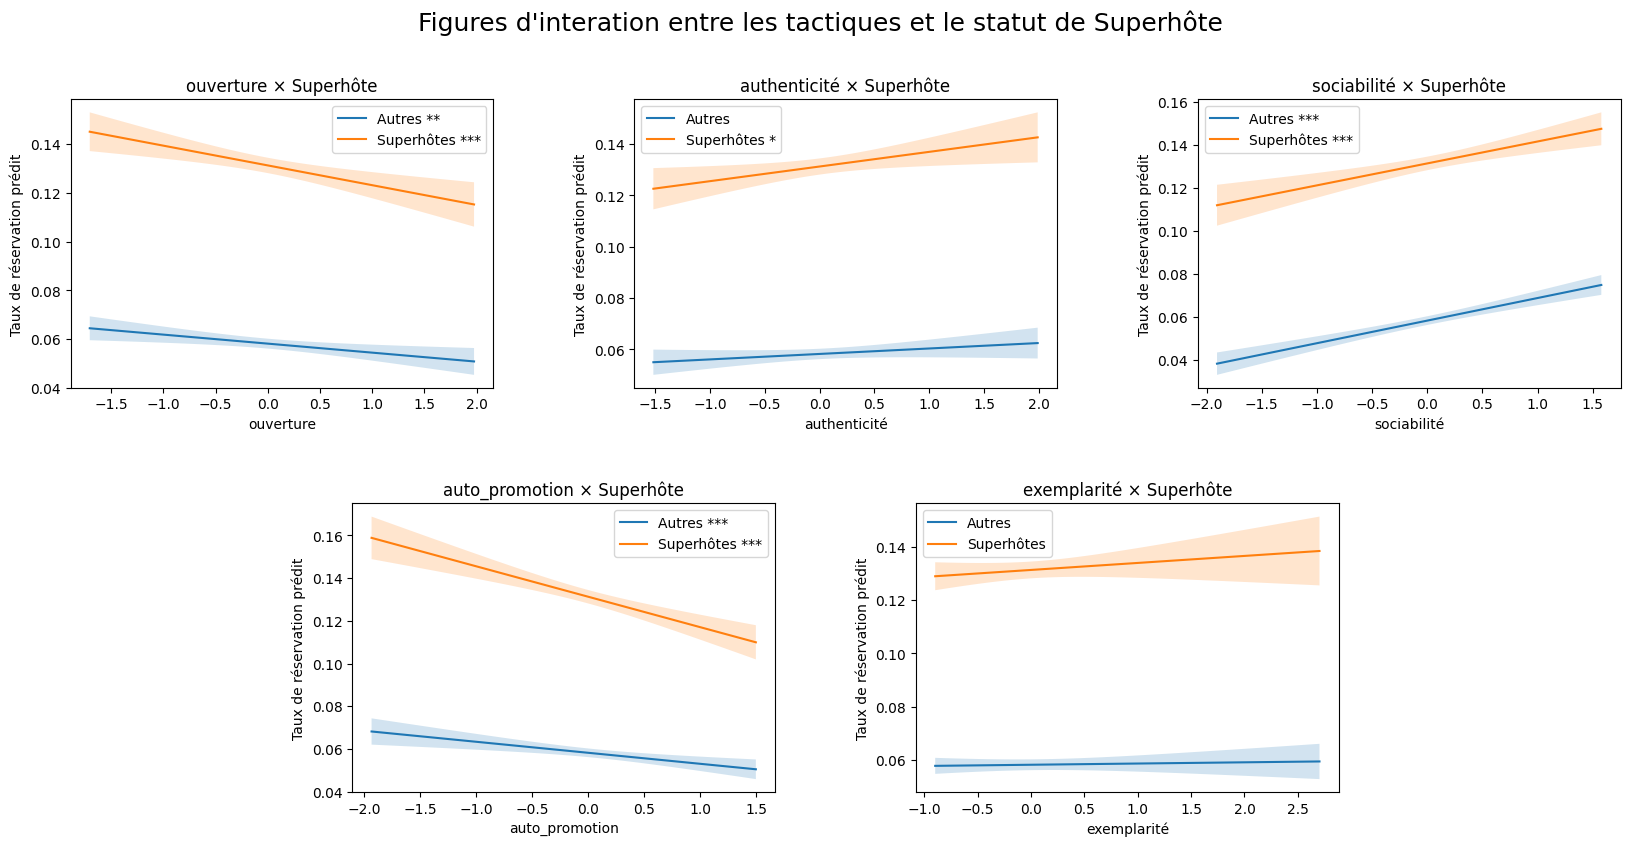

In [41]:
importlib.reload(modeling)
from utils.modeling import modeling_main

OUTPUT_FOLDER_MOD=Path("../output_mod_bge/booking90-pro")

modeling_main(df_input=df_reviews, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col="professional_host",
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

# modernbert XXX


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:38: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  #output
d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[INFO] df_items : 74579 rows!
[INFO] all output saved to '..\output_fa'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:31429

[INFO] kmo_model score (> 0.7) :0.8609101802056964

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5


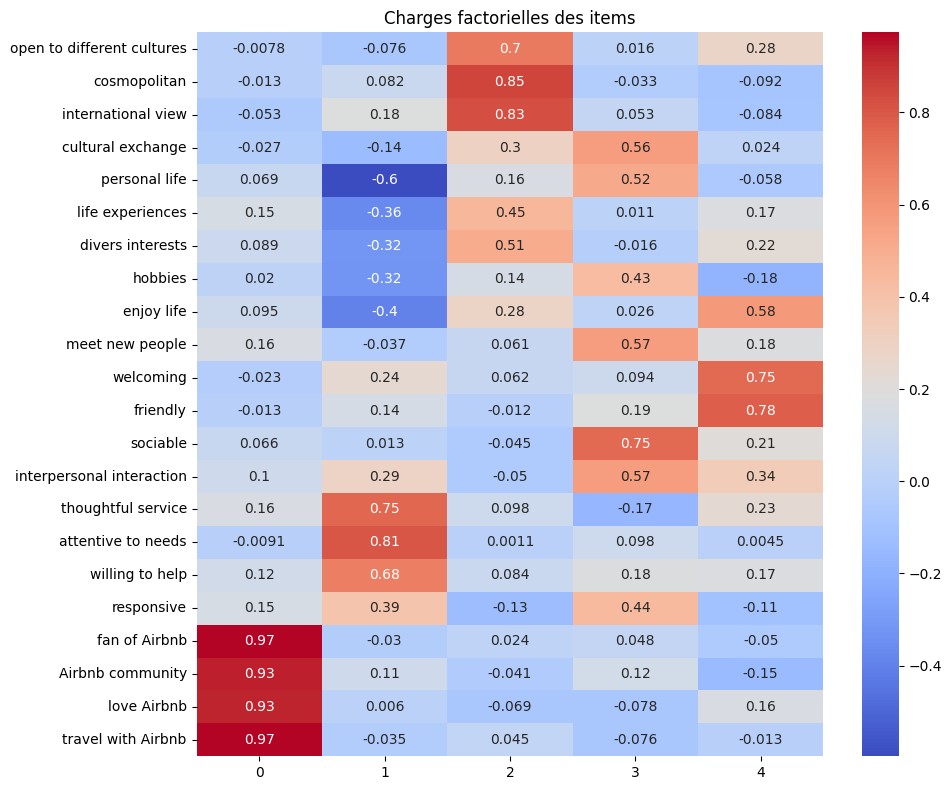

✅ [SAVE] heatmap of items saved to ..\output_fa\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------
# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6229037720898133
[INFO] mean UNIQ : 0.37709622791018677

[WARNING] 6/22 low communality items (< 0.5):
cultural exchange;life experiences;divers interests;hobbies;meet new people;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
[INFO] shape df scores = 5*len(get_factor_scores_by):(31429, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
0,0.356631,0.106891
1,0.021459,0.999294
2,0.540444,-0.340369
3,0.543841,-0.047489
4,0.733773,0.150587


✅[SAVE] scores df saved to ..\output_fa\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


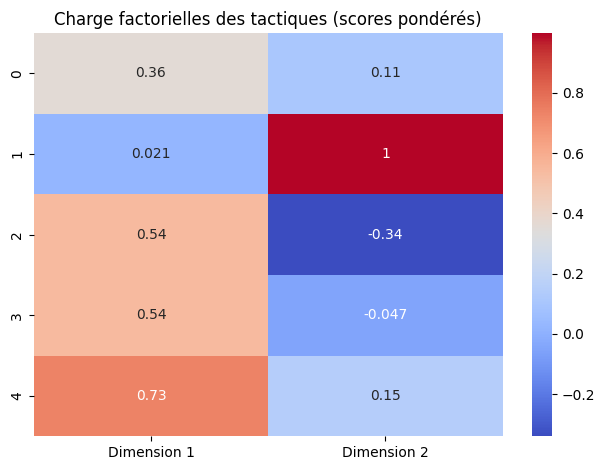

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,thoughtful service,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,0,1,2,3,4
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.065833,0.022141,0.017699,0.009170,0.006907,-0.710757,-0.361215,-0.073375,-0.253538,-1.059896
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.988275,0.176687,0.093593,0.312114,0.076266,-0.097498,1.450847,0.406596,-0.620695,1.851329
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.028080,0.017159,0.002388,0.004195,0.002107,-0.675543,-1.583517,-0.472648,-0.975028,-1.417002
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.015022,0.224744,0.022929,0.112141,0.515647,0.044175,-1.534926,1.729179,0.481689,1.282317


[INFO] scores shape (len(data), 1/2*n_factors) :(31429, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 31429, 31429, 31429
len(DF)==len(listings_tactics):74579,74579

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed\../data_processed\listings_paris2406_scores.csv!!

###====================================CHECK=======================================###
[CHECK] get cronbach's alpha need dict_factor_items!!


In [ ]:
importlib.reload(fa)
from utils.fa import run_fa


PATH_DF_ITEMS="../data_processed\listings_paris2406_items_modernbert.csv"
OUTPUT_FOLDER=Path("../output_fa")
OUTPUT_FOLDER_DATA=Path("../data_processed")


run_fa(path_df_items=PATH_DF_ITEMS, items=LABELS_EN, 
       output_folder=OUTPUT_FOLDER,
        output_folder_data=OUTPUT_FOLDER_DATA,
        n_factors=5, rotation="oblimin", 
        fa_names=None,
        dict_factor_items=None,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        round=4)